In [1]:
# Install physics and rendering dependencies
!apt-get install -y xvfb x11-utils > /dev/null 2>&1
!pip install pyvirtualdisplay imageio[ffmpeg] mujoco>=3.1.0 gymnasium[mujoco]>=0.29.0 > /dev/null 2>&1

# Start the virtual display for headless rendering
import pyvirtualdisplay
display = pyvirtualdisplay.Display(visible=0, size=(1400, 900))
display.start()
print("Dependencies installed and virtual display started.")

Dependencies installed and virtual display started.


In [2]:
# ================================================================
# CELL 4: Complete DMG Implementation
#
# Components:
#   MLP                 - Generic feedforward network
#   ValueNetwork        - V(s) via expectile regression
#   TwinQNetwork        - Double Q(s,a) for clipped double Q
#   SinusoidalTimeEmbed - DDPM timestep embedding
#   ScoreNetwork        - epsilon_theta(a_t, s, t)
#   GaussianDiffusion   - DDPM forward / reverse process
#   OfflineBuffer       - Offline D4RL replay buffer
#   DMGAgent            - Full algorithm: V + Q + Actor updates
# ================================================================

import math
import time
from copy    import deepcopy
from typing  import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass


# ------------------------------------------------------------------
# 1.  MLP
# ------------------------------------------------------------------

class MLP(nn.Module):
    """Generic multi-layer perceptron with configurable depth and activation.

    Args:
        input_dim:    Input feature dimensionality.
        output_dim:   Output feature dimensionality.
        hidden_dims:  List of hidden layer widths.
        activation:   Activation class applied after each hidden layer.
    """
    def __init__(
        self,
        input_dim:   int,
        output_dim:  int,
        hidden_dims: List[int],
        activation:  type = nn.ReLU,
    ) -> None:
        super().__init__()
        layers: List[nn.Module] = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), activation()]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ------------------------------------------------------------------
# 2.  Value Network  V(s)
# ------------------------------------------------------------------

class ValueNetwork(nn.Module):
    """State-value function V(s) trained with expectile regression.

    V(s) converges to the τ-quantile of {Q(s,a) : a in dataset},
    providing a safe, in-sample upper bound on action values.

    Args:
        state_dim:  Dimensionality of the observation space.
        hidden_dim: Width of each hidden layer (paper: 256).
        n_hidden:   Number of hidden layers (paper: 3).
    """
    def __init__(self, state_dim: int, hidden_dim: int = 256, n_hidden: int = 3):
        super().__init__()
        self.net = MLP(state_dim, 1, [hidden_dim] * n_hidden)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """Returns V(s) of shape (batch,)."""
        return self.net(state).squeeze(-1)


# ------------------------------------------------------------------
# 3.  Twin Q-Network  Q(s, a)
# ------------------------------------------------------------------

class TwinQNetwork(nn.Module):
    """Double Q-network to reduce overestimation bias (Fujimoto et al., 2018).

    Maintains two independent Q-heads; training uses both,
    inference uses min(Q1, Q2) for conservative evaluation.

    Args:
        state_dim:  Dimensionality of the observation space.
        action_dim: Dimensionality of the action space.
        hidden_dim: Width of each hidden layer.
        n_hidden:   Number of hidden layers.
    """
    def __init__(self, state_dim: int, action_dim: int,
                 hidden_dim: int = 256, n_hidden: int = 3):
        super().__init__()
        inp = state_dim + action_dim
        dims = [hidden_dim] * n_hidden
        self.q1 = MLP(inp, 1, dims)
        self.q2 = MLP(inp, 1, dims)

    def both(self, state: torch.Tensor, action: torch.Tensor
             ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Returns (Q1(s,a), Q2(s,a)) each of shape (batch,)."""
        x = torch.cat([state, action], dim=-1)
        return self.q1(x).squeeze(-1), self.q2(x).squeeze(-1)

    def forward(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        """Returns min(Q1, Q2) of shape (batch,)."""
        return torch.min(*self.both(state, action))


# ------------------------------------------------------------------
# 4.  Sinusoidal Time Embedding  (DDPM)
# ------------------------------------------------------------------

class SinusoidalTimeEmbed(nn.Module):
    """Maps integer diffusion timestep t to a dense embedding.

    Uses sinusoidal encoding (Vaswani et al., 2017) followed by
    a 2-layer SiLU MLP to produce a learnable time representation.

    Args:
        embed_dim: Output embedding dimensionality (paper: 128).
    """
    def __init__(self, embed_dim: int = 128):
        super().__init__()
        half = embed_dim // 2
        freqs = torch.exp(
            -math.log(10_000) * torch.arange(half, dtype=torch.float32) / half
        )
        self.register_buffer("freqs", freqs)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4), nn.SiLU(),
            nn.Linear(embed_dim * 4, embed_dim), nn.SiLU(),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """Args:  t of shape (batch,) integer. Returns (batch, embed_dim)."""
        sinusoid = t.float().unsqueeze(-1) * self.freqs  # (B, half)
        emb = torch.cat([sinusoid.sin(), sinusoid.cos()], dim=-1)
        return self.mlp(emb)


# ------------------------------------------------------------------
# 5.  Diffusion Score Network  ε_θ(a_t, s, t)
# ------------------------------------------------------------------

class ScoreNetwork(nn.Module):
    """Noise-prediction network for the conditional DDPM policy.

    Given noisy action a_t, state conditioning s, and timestep t,
    predicts the noise ε that was added during the forward process.

    Architecture: [a_t, s, embed(t)] → 3-layer ReLU MLP → ε̂

    Args:
        state_dim:     Dimensionality of the state space.
        action_dim:    Dimensionality of the action space.
        hidden_dim:    Width of each hidden layer.
        time_embed_dim: Dimensionality of the sinusoidal time embedding.
        n_hidden:      Number of hidden layers.
    """
    def __init__(self, state_dim: int, action_dim: int,
                 hidden_dim: int = 256, time_embed_dim: int = 128,
                 n_hidden: int = 3):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbed(time_embed_dim)
        inp = state_dim + action_dim + time_embed_dim
        self.net = MLP(inp, action_dim, [hidden_dim] * n_hidden)

    def forward(self, a_noisy: torch.Tensor, state: torch.Tensor,
                t: torch.Tensor) -> torch.Tensor:
        """Returns predicted noise ε̂ of shape (batch, action_dim)."""
        t_emb = self.time_embed(t)
        x = torch.cat([a_noisy, state, t_emb], dim=-1)
        return self.net(x)


# ------------------------------------------------------------------
# 6.  Gaussian Diffusion Process  (DDPM)
# ------------------------------------------------------------------

class GaussianDiffusion(nn.Module):
    """DDPM forward and reverse processes for action generation.

    Uses a linear beta schedule with T steps (paper uses T=5 for efficiency).

    Forward (noising):  q(a_t | a_0) = N(√ᾱ_t · a_0, (1-ᾱ_t) · I)
    Reverse (denoising): p_θ(a_{t-1} | a_t, s) parameterised by ScoreNetwork

    Args:
        score_net:   The ε_θ noise-prediction network.
        action_dim:  Dimensionality of the action space.
        T:           Number of diffusion steps.
        beta_start:  Starting β for the noise schedule.
        beta_end:    Ending β for the noise schedule.
        action_clip: Clamp sampled actions to [-clip, +clip].
    """
    def __init__(self, score_net: ScoreNetwork, action_dim: int,
                 T: int = 5, beta_start: float = 0.1, beta_end: float = 10.0,
                 action_clip: float = 1.0):
        super().__init__()
        self.score_net  = score_net
        self.action_dim = action_dim
        self.T          = T
        self.clip       = action_clip

        # Pre-compute noise schedule buffers
        betas    = torch.linspace(beta_start / T, beta_end / T, T).clamp(max=0.999)
        alphas   = 1.0 - betas
        alpha_bar      = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = torch.cat([torch.ones(1), alpha_bar[:-1]])

        self.register_buffer("betas",         betas)
        self.register_buffer("alphas",        alphas)
        self.register_buffer("alpha_bar",     alpha_bar)
        self.register_buffer("alpha_bar_prev",alpha_bar_prev)
        self.register_buffer("sqrt_ab",       alpha_bar.sqrt())
        self.register_buffer("sqrt_1mab",     (1.0 - alpha_bar).sqrt())

    # ---- Forward process -------------------------------------------------

    def q_sample(self, a0: torch.Tensor, t: torch.Tensor,
                 noise: torch.Tensor) -> torch.Tensor:
        """Corrupt a0 to a_t:  a_t = √ᾱ_t·a0 + √(1-ᾱ_t)·ε"""
        sa  = self.sqrt_ab[t].unsqueeze(-1)     # (B,1)
        s1a = self.sqrt_1mab[t].unsqueeze(-1)   # (B,1)
        return sa * a0 + s1a * noise

    # ---- Training loss ---------------------------------------------------

    def loss(self, a0: torch.Tensor, state: torch.Tensor) -> torch.Tensor:
        """L_simple: MSE between true noise and predicted noise.

        L = E_{t, a0, ε}[ ‖ε - ε_θ(q_sample(a0,t,ε), s, t)‖² ]
        """
        B = a0.shape[0]
        t     = torch.randint(0, self.T, (B,), device=a0.device)
        noise = torch.randn_like(a0)
        a_t   = self.q_sample(a0, t, noise)
        pred  = self.score_net(a_t, state, t)
        return F.mse_loss(pred, noise)

    # ---- Reverse process (sampling) ---------------------------------------

    @torch.no_grad()
    def sample(self, state: torch.Tensor, n_samples: int = 1) -> torch.Tensor:
        """DDPM ancestral sampling: a_T → a_{T-1} → ... → a_0.

        Args:
            state:     Conditioning context of shape (batch, state_dim).
            n_samples: Number of candidate actions per state.

        Returns:
            Denoised actions of shape (batch * n_samples, action_dim).
        """
        B  = state.shape[0]
        # Repeat each state n_samples times
        s  = state.unsqueeze(1).expand(-1, n_samples, -1).reshape(B * n_samples, -1)
        a  = torch.randn(B * n_samples, self.action_dim, device=state.device)

        for i in reversed(range(self.T)):
            t_vec    = torch.full((B * n_samples,), i, device=state.device, dtype=torch.long)
            eps_pred = self.score_net(a, s, t_vec)

            # DDPM reverse mean
            coef = self.betas[i] / self.sqrt_1mab[i]
            mean = (a - coef * eps_pred) / self.alphas[i].sqrt()

            if i > 0:
                sigma = (
                    (1 - self.alpha_bar_prev[i]) / (1 - self.alpha_bar[i])
                    * self.betas[i]
                ).sqrt()
                a = mean + sigma * torch.randn_like(a)
            else:
                a = mean   # final step: no added noise

        return a.clamp(-self.clip, self.clip)


# ------------------------------------------------------------------
# 7.  Expectile Loss
# ------------------------------------------------------------------

def expectile_loss(diff: torch.Tensor, tau: float) -> torch.Tensor:
    """Asymmetric squared loss for expectile regression.

    L_τ(u) = |τ - 1(u < 0)| · u²

    When τ > 0.5: positive residuals (Q > V) are penalised more
    heavily, so V(s) converges toward the upper quantile of Q(s,·).

    Args:
        diff: Residuals Q(s,a) - V(s), shape (batch,).
        tau:  Expectile level. Paper uses τ = 0.7 for locomotion.

    Returns:
        Per-element loss of shape (batch,).
    """
    weight = torch.where(diff >= 0,
                         torch.full_like(diff, tau),
                         torch.full_like(diff, 1.0 - tau))
    return weight * diff.pow(2)


# ------------------------------------------------------------------
# 8.  Offline Replay Buffer
# ------------------------------------------------------------------

@dataclass
class Batch:
    """Container for a mini-batch of transitions."""
    states:      torch.Tensor
    actions:     torch.Tensor
    rewards:     torch.Tensor
    next_states: torch.Tensor
    dones:       torch.Tensor


class OfflineBuffer:
    """Static offline replay buffer backed by pre-loaded tensors.

    Optionally normalises rewards by |mean| to stabilise critic
    training across environments with differing reward scales.

    Args:
        dataset:           Dict with numpy arrays from load_d4rl_hdf5().
        device:            Torch device string.
        normalize_rewards: Divide rewards by |mean reward|.
    """
    def __init__(self, dataset: dict, device: str = "cpu",
                 normalize_rewards: bool = True):
        to = lambda arr: torch.from_numpy(arr).float().to(device)
        self.states      = to(dataset["observations"])
        self.actions     = to(dataset["actions"])
        self.rewards     = to(dataset["rewards"])
        self.next_states = to(dataset["next_observations"])
        self.dones       = to(dataset["terminals"])
        self.size        = self.states.shape[0]
        self.device      = device

        if normalize_rewards:
            scale = self.rewards.abs().mean().clamp(min=1e-5)
            self.rewards = self.rewards / scale
            print(f"Reward normalisation scale: {scale.item():.4f}")

    def sample(self, batch_size: int) -> Batch:
        """Sample a random mini-batch of transitions."""
        idx = torch.randint(0, self.size, (batch_size,), device=self.device)
        return Batch(
            states      = self.states[idx],
            actions     = self.actions[idx],
            rewards     = self.rewards[idx],
            next_states = self.next_states[idx],
            dones       = self.dones[idx],
        )


# ------------------------------------------------------------------
# 9.  DMG Agent  (Full Algorithm)
# ------------------------------------------------------------------

class DMGAgent(nn.Module):
    """Doubly Mild Generalization offline RL agent.

    Implements three interleaved update steps per gradient iteration:

      (i)  V-update:  Expectile regression.
           L_V = E[ L_τ(Q(s,a) - V(s)) ]   where L_τ is asymmetric L2.

      (ii) Q-update:  Blended Bellman target.
           y = r + γ · [(1-λ)·V(s') + λ·min_Q_target(s', ã')]
           ã' = argmax_a Q_target(s', a) over diffusion-sampled candidates

      (iii) Actor-update: Advantage-weighted diffusion BC.
           L_π = E[ ((1-ν) + ν·exp(A(s,a)/β)) · L_BC(a, s) ]

    The target Q-network is updated via Polyak EMA after every step.

    Args:
        state_dim:    Observation space dimensionality.
        action_dim:   Action space dimensionality.
        max_action:   Absolute bound on each action dimension.
        lam:          Mixture coefficient λ ∈ [0,1]. (paper: 0.25)
        nu:           Advantage guidance weight ν. (paper: 0.1)
        tau:          Expectile level τ for V(s). (paper: 0.7)
        discount:     MDP discount factor γ.
        T:            DDPM diffusion steps. (paper: 5)
        n_candidates: Action candidates sampled per state at eval.
        hidden_dim:   Hidden layer width. (paper: 256)
        actor_lr:     Learning rate for the diffusion policy.
        critic_lr:    Learning rate for Q and V.
        ema_tau:      EMA coefficient for Q-target soft update.
        beta_adv:     Temperature β in exp(A/β) advantage weighting.
        clip_score:   Max value for advantage weight (numerical stability).
        device:       Torch device string.
    """
    def __init__(
        self,
        state_dim:    int,
        action_dim:   int,
        max_action:   float = 1.0,
        lam:          float = 0.25,
        nu:           float = 0.1,
        tau:          float = 0.7,
        discount:     float = 0.99,
        T:            int   = 5,
        n_candidates: int   = 10,
        hidden_dim:   int   = 256,
        actor_lr:     float = 3e-4,
        critic_lr:    float = 3e-4,
        ema_tau:      float = 0.005,
        beta_adv:     float = 1.0,
        clip_score:   float = 100.0,
        device:       str   = "cpu",
    ) -> None:
        super().__init__()
        # Hyperparameters
        self.lam        = lam
        self.nu         = nu
        self.tau        = tau
        self.discount   = discount
        self.n_cands    = n_candidates
        self.ema_tau    = ema_tau
        self.max_action = max_action
        self.beta_adv   = beta_adv
        self.clip_score = clip_score
        self.device     = device

        # Networks
        self.V     = ValueNetwork(state_dim, hidden_dim).to(device)
        self.Q     = TwinQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.Q_tgt = deepcopy(self.Q).to(device)
        for p in self.Q_tgt.parameters():
            p.requires_grad_(False)

        score_net    = ScoreNetwork(state_dim, action_dim, hidden_dim)
        self.diffusion = GaussianDiffusion(
            score_net, action_dim, T=T, action_clip=max_action
        ).to(device)

        # Optimisers
        self.V_opt = torch.optim.Adam(self.V.parameters(),               lr=critic_lr)
        self.Q_opt = torch.optim.Adam(self.Q.parameters(),               lr=critic_lr)
        self.A_opt = torch.optim.Adam(
            self.diffusion.score_net.parameters(), lr=actor_lr
        )

    # ----------------------------------------------------------------
    # Private: EMA soft update for Q-target
    # ----------------------------------------------------------------

    def _ema_update(self) -> None:
        """θ_tgt ← (1 - τ_ema)·θ_tgt + τ_ema·θ_online"""
        with torch.no_grad():
            for p_on, p_tgt in zip(self.Q.parameters(), self.Q_tgt.parameters()):
                p_tgt.data.mul_(1.0 - self.ema_tau).add_(p_on.data, alpha=self.ema_tau)

    # ----------------------------------------------------------------
    # Update steps
    # ----------------------------------------------------------------

    def _update_value(self, b: Batch) -> float:
        """Update V(s) via expectile regression against frozen Q-target.

        L_V = E_{(s,a)~D}[ L_τ( min(Q1_tgt, Q2_tgt)(s,a) - V(s) ) ]
        """
        with torch.no_grad():
            q_tgt = self.Q_tgt(b.states, b.actions)  # min(Q1, Q2)
        v    = self.V(b.states)
        loss = expectile_loss(q_tgt - v, self.tau).mean()
        self.V_opt.zero_grad()
        loss.backward()
        self.V_opt.step()
        return loss.item()

    def _update_q(self, b: Batch) -> float:
        """Update Q(s,a) with the doubly mild blended Bellman target.

        Target y = r + γ·[ (1-λ)·V(s')  +  λ·max_{ã} Q_tgt(s', ã) ]

        The first term (in-sample IQL backup) is safe by construction.
        The second term (mild OOD backup) uses diffusion-sampled actions.
        λ linearly interpolates between the two, controlling overestimation.
        """
        with torch.no_grad():
            v_next = self.V(b.next_states)                 # (B,)
            B      = b.next_states.shape[0]
            n      = self.n_cands

            # Sample n candidate actions from the diffusion policy at s'
            a_cands  = self.diffusion.sample(b.next_states, n)  # (B*n, adim)
            s_rep    = (
                b.next_states
                .unsqueeze(1).expand(-1, n, -1)
                .reshape(B * n, -1)
            )
            q_best   = (
                self.Q_tgt(s_rep, a_cands)
                .reshape(B, n).max(dim=1).values            # (B,)
            )

            # Blended Bellman target  (core DMG equation)
            target   = b.rewards + self.discount * (1.0 - b.dones) * (
                (1.0 - self.lam) * v_next + self.lam * q_best
            )

        q1, q2 = self.Q.both(b.states, b.actions)
        loss   = F.mse_loss(q1, target) + F.mse_loss(q2, target)
        self.Q_opt.zero_grad()
        loss.backward()
        self.Q_opt.step()
        return loss.item()

    def _update_actor(self, b: Batch) -> float:
        """Update diffusion policy with advantage-weighted BC loss.

        L_π = E[ w(s,a) · ‖ε̂ - ε‖² ]   where
        w(s,a) = (1-ν) + ν · exp( (Q(s,a)-V(s)) / β )

        When A>0: w>1, BC loss amplified → policy steered toward good actions.
        When A<0: w<1, BC loss attenuated → bad actions de-emphasised.
        ν=0: pure BC.  ν=1: full advantage-weighted.
        """
        with torch.no_grad():
            adv   = self.Q(b.states, b.actions) - self.V(b.states)
            # Normalise advantages per-batch for numerical stability
            adv_n = (adv - adv.mean()) / (adv.std() + 1e-6)
            # math.log(100.0) is approx 4.605
            weight = (
                      (1.0 - self.nu)
                        + self.nu * torch.exp((adv_n / self.beta_adv).clamp(max=math.log(self.clip_score)))
)

        # Per-sample diffusion loss
        T_d   = self.diffusion.T
        t     = torch.randint(0, T_d, (b.actions.shape[0],), device=self.device)
        noise = torch.randn_like(b.actions)
        a_t   = self.diffusion.q_sample(b.actions, t, noise)
        pred  = self.diffusion.score_net(a_t, b.states, t)

        # Mean over action dim, weight over batch dim
        per_sample_loss = F.mse_loss(pred, noise, reduction="none").mean(dim=-1)
        loss = (weight * per_sample_loss).mean()

        self.A_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            self.diffusion.score_net.parameters(), max_norm=1.0
        )
        self.A_opt.step()
        return loss.item()

    # ----------------------------------------------------------------
    # Public: full training step
    # ----------------------------------------------------------------

    def train_step(self, batch: Batch) -> Dict[str, float]:
        """Execute one full DMG gradient step (V → Q → Actor → EMA).

        Args:
            batch: Mini-batch of offline transitions.

        Returns:
            Dict of scalar losses for logging.
        """
        self.train()
        v_loss = self._update_value(batch)
        q_loss = self._update_q(batch)
        a_loss = self._update_actor(batch)
        self._ema_update()
        return {"V_loss": v_loss, "Q_loss": q_loss, "A_loss": a_loss}

    # ----------------------------------------------------------------
    # Public: inference
    # ----------------------------------------------------------------

    @torch.no_grad()
    def select_action(self, state: np.ndarray) -> np.ndarray:
        """Select action for a single state at evaluation time.

        Samples n_candidates actions from the diffusion policy and
        returns the one with the highest Q-value.
        This is the 'mild action generalization' at inference.

        Args:
            state: Numpy array of shape (state_dim,).

        Returns:
            Numpy array of shape (action_dim,).
        """
        self.eval()
        s       = torch.from_numpy(state).float().unsqueeze(0).to(self.device)
        cands   = self.diffusion.sample(s, n_samples=self.n_cands)  # (n, adim)
        s_rep   = s.expand(self.n_cands, -1)                        # (n, sdim)
        q_vals  = self.Q(s_rep, cands)                              # (n,)
        best    = q_vals.argmax()
        return cands[best].cpu().numpy()


print("✓ DMG implementation loaded.")
print("  Classes: MLP, ValueNetwork, TwinQNetwork, SinusoidalTimeEmbed,")
print("           ScoreNetwork, GaussianDiffusion, OfflineBuffer, DMGAgent")
print("  Functions: expectile_loss")

✓ DMG implementation loaded.
  Classes: MLP, ValueNetwork, TwinQNetwork, SinusoidalTimeEmbed,
           ScoreNetwork, GaussianDiffusion, OfflineBuffer, DMGAgent
  Functions: expectile_loss


In [12]:
import torch
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import Video
import os

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Make sure this path matches where you uploaded the file in Step 1!
CHECKPOINT_PATH = "/content/dmg_halfcheetah_medium_v2.pt"
VIDEO_DIR = "./dmg_demo_video"

# 1. Load the checkpoint dictionary
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

# 2. Reconstruct the agent using the saved hyperparameters
agent = DMGAgent(
    state_dim=17,
    action_dim=6,
    lam=checkpoint["hyperparameters"]["lam"],
    nu=checkpoint["hyperparameters"]["nu"],
    tau=checkpoint["hyperparameters"]["tau"],
    T=checkpoint["hyperparameters"]["T"],
    n_candidates=checkpoint["hyperparameters"]["n_cands"],
    device=DEVICE
)

# Load the trained weights into the blueprint
agent.load_state_dict(checkpoint["agent_state_dict"])
agent.eval()
print("Model weights loaded successfully.")

# 3. Create the environment and wrap it for video recording
# Adding camera_name="front" or "track" (depending on the exact XML version) forces the camera to follow the agent
base_env = gym.make("HalfCheetah-v4", render_mode="rgb_array", camera_name="track")
env = RecordVideo(
    base_env,
    video_folder=VIDEO_DIR,
    episode_trigger=lambda ep: True, # Record every episode
    name_prefix="dmg_halfcheetah"
)

# 4. Run the demonstration loop
N_DEMO_EPISODES = 3

for ep in range(N_DEMO_EPISODES):
    obs, _ = env.reset(seed=42 + ep)
    done = False
    ep_reward = 0.0

    while not done:
        action = agent.select_action(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_reward += reward
        done = terminated or truncated

    print(f"Demo Episode {ep+1} | Total Reward: {ep_reward:.1f}")

env.close()
print(f"Video saved to {VIDEO_DIR}")

Model weights loaded successfully.
Demo Episode 1 | Total Reward: 5917.7
Demo Episode 2 | Total Reward: 6114.7
Demo Episode 3 | Total Reward: 5073.7
Video saved to ./dmg_demo_video


In [13]:
import glob
import os
from IPython.display import Video
from IPython.display import display as ipydisplay  # Renamed to avoid the clash

# Find the most recently recorded mp4 file
mp4_files = glob.glob(f"{VIDEO_DIR}/*.mp4")
if mp4_files:
    latest_video = max(mp4_files, key=os.path.getctime)
    print(f"Playing: {latest_video}")
    # Use the specific IPython display function
    ipydisplay(Video(latest_video, embed=True, width=640))
else:
    print("No video found.")

Playing: ./dmg_demo_video/dmg_halfcheetah-episode-2.mp4


Hopper dataset ready.
Reward normalisation scale: 3.1088

Training Hopper | State Dim: 11 | Action Dim: 3


Training Hopper:   0%|          | 0/150000 [00:00<?, ?it/s]

[Step  5000] Return: 16.5 | Norm Score: 1.1
[Step 10000] Return: 30.7 | Norm Score: 1.6
[Step 15000] Return: 46.3 | Norm Score: 2.0
[Step 20000] Return: 6.1 | Norm Score: 0.8
[Step 25000] Return: 126.1 | Norm Score: 4.5
[Step 30000] Return: 287.5 | Norm Score: 9.5
[Step 35000] Return: 508.5 | Norm Score: 16.2
[Step 40000] Return: 289.0 | Norm Score: 9.5
[Step 45000] Return: 438.1 | Norm Score: 14.1
[Step 50000] Return: 486.1 | Norm Score: 15.6
[Step 55000] Return: 594.4 | Norm Score: 18.9
[Step 60000] Return: 464.6 | Norm Score: 14.9
[Step 65000] Return: 791.9 | Norm Score: 25.0
[Step 70000] Return: 812.2 | Norm Score: 25.6
[Step 75000] Return: 64.5 | Norm Score: 2.6
[Step 80000] Return: 1024.7 | Norm Score: 32.1
[Step 85000] Return: 177.4 | Norm Score: 6.1
[Step 90000] Return: 1183.4 | Norm Score: 37.0
[Step 95000] Return: 735.0 | Norm Score: 23.2
[Step 100000] Return: 852.5 | Norm Score: 26.8
[Step 105000] Return: 854.1 | Norm Score: 26.9
[Step 110000] Return: 747.5 | Norm Score: 23.

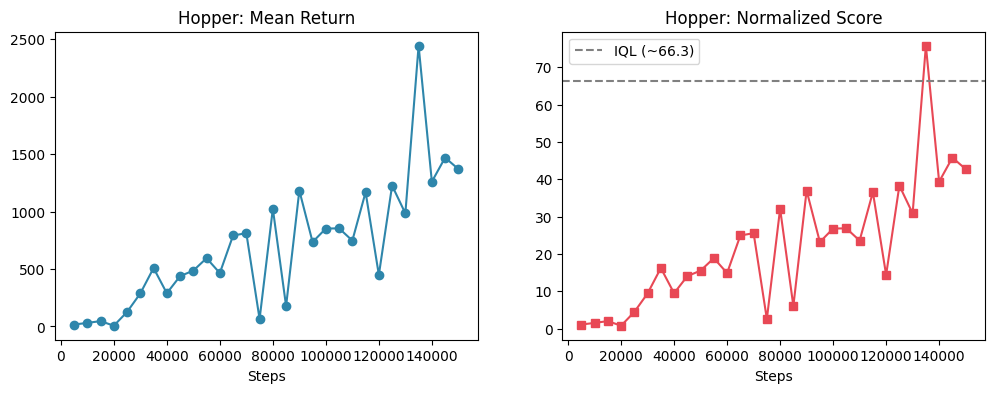

In [8]:
# ================================================================
# EXPERIMENT 2: Hopper-v4 (Fast-Track)
# ================================================================
import os
import urllib.request
import h5py
import numpy as np
import torch
import gymnasium as gym
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# 1. Define Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Download Dataset
HOPPER_URL = "http://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/hopper_medium-v2.hdf5"
HOPPER_PATH = "/content/hopper_medium_v2.hdf5"

if not os.path.exists(HOPPER_PATH):
    print("Downloading Hopper dataset...")
    urllib.request.urlretrieve(HOPPER_URL, HOPPER_PATH)
print("Hopper dataset ready.")

# Load dataset
with h5py.File(HOPPER_PATH, 'r') as f:
    dataset_hop = {
        'observations':      np.array(f['observations'],      dtype=np.float32),
        'actions':           np.array(f['actions'],           dtype=np.float32),
        'rewards':           np.array(f['rewards'],           dtype=np.float32),
        'next_observations': np.array(f['next_observations'], dtype=np.float32),
        'terminals':         np.array(f['terminals'],         dtype=np.float32),
    }

# 3. Setup Environment & Agent
env_hop = gym.make("Hopper-v4")
STATE_DIM_H  = env_hop.observation_space.shape[0]
ACTION_DIM_H = env_hop.action_space.shape[0]
MAX_ACTION_H = float(env_hop.action_space.high[0])

buffer_hop = OfflineBuffer(dataset_hop, device=DEVICE, normalize_rewards=True)

agent_hop = DMGAgent(
    state_dim=STATE_DIM_H, action_dim=ACTION_DIM_H, max_action=MAX_ACTION_H,
    lam=0.25, nu=0.1, tau=0.7, T=5, n_candidates=10, device=DEVICE
)

# Hopper D4RL Constants
HOP_RANDOM = -20.272305
HOP_EXPERT = 3234.3
def norm_score_hop(ret): return (ret - HOP_RANDOM) / (HOP_EXPERT - HOP_RANDOM) * 100

# 4. Training Loop
N_STEPS = 150_000
EVAL_FREQ = 5_000
N_EVAL_EPS = 5
eval_steps_h, eval_returns_h, eval_nscores_h = [], [], []

agent_hop = torch.compile(agent_hop) # PyTorch JIT compiler for extra speed

print(f"\nTraining Hopper | State Dim: {STATE_DIM_H} | Action Dim: {ACTION_DIM_H}")
for step in tqdm(range(1, N_STEPS + 1), desc="Training Hopper"):
    batch = buffer_hop.sample(256)
    agent_hop.train_step(batch)

    if step % EVAL_FREQ == 0:
        agent_hop.eval()
        rets = []
        for ep in range(5):
            s, _ = env_hop.reset(seed=ep)
            done, ep_ret = False, 0.0
            while not done:
                a = agent_hop.select_action(s)
                s, r, term, trunc, _ = env_hop.step(a)
                ep_ret += r
                done = term or trunc
            rets.append(ep_ret)
        mean_r = np.mean(rets)
        norm_s = norm_score_hop(mean_r)
        eval_steps_h.append(step)
        eval_returns_h.append(mean_r)
        eval_nscores_h.append(norm_s)
        tqdm.write(f"[Step {step:>5d}] Return: {mean_r:.1f} | Norm Score: {norm_s:.1f}")
        agent_hop.train()

# 5. Plot Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(eval_steps_h, eval_returns_h, marker='o', color='#2E86AB')
ax1.set_title("Hopper: Mean Return"); ax1.set_xlabel("Steps")
ax2.plot(eval_steps_h, eval_nscores_h, marker='s', color='#E84855')
ax2.axhline(66.3, color='gray', linestyle='--', label='IQL (~66.3)')
ax2.set_title("Hopper: Normalized Score"); ax2.set_xlabel("Steps"); ax2.legend()
plt.savefig("./dmg_results_hopper.png", bbox_inches='tight')
plt.show()

Walker2d dataset ready.
Reward normalisation scale: 3.3986

Training Walker2d | State Dim: 17 | Action Dim: 6


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Walker2d-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Training Walker2d:   0%|          | 0/150000 [00:00<?, ?it/s]

[Step  5000] Return: -2.0 | Norm Score: -0.1
[Step 10000] Return: -1.5 | Norm Score: -0.1
[Step 15000] Return: -2.2 | Norm Score: -0.1
[Step 20000] Return: 4.9 | Norm Score: 0.1
[Step 25000] Return: 33.3 | Norm Score: 0.7
[Step 30000] Return: 12.7 | Norm Score: 0.2
[Step 35000] Return: 9.9 | Norm Score: 0.2
[Step 40000] Return: -2.8 | Norm Score: -0.1
[Step 45000] Return: -3.2 | Norm Score: -0.1
[Step 50000] Return: 2.9 | Norm Score: 0.0
[Step 55000] Return: -0.9 | Norm Score: -0.1
[Step 60000] Return: -1.0 | Norm Score: -0.1
[Step 65000] Return: -0.2 | Norm Score: -0.0
[Step 70000] Return: 36.0 | Norm Score: 0.7
[Step 75000] Return: -4.5 | Norm Score: -0.1
[Step 80000] Return: 14.2 | Norm Score: 0.3
[Step 85000] Return: 11.6 | Norm Score: 0.2
[Step 90000] Return: 4.2 | Norm Score: 0.1
[Step 95000] Return: -3.4 | Norm Score: -0.1
[Step 100000] Return: 12.8 | Norm Score: 0.2
[Step 105000] Return: 1.3 | Norm Score: -0.0
[Step 110000] Return: 9.5 | Norm Score: 0.2
[Step 115000] Return: -3

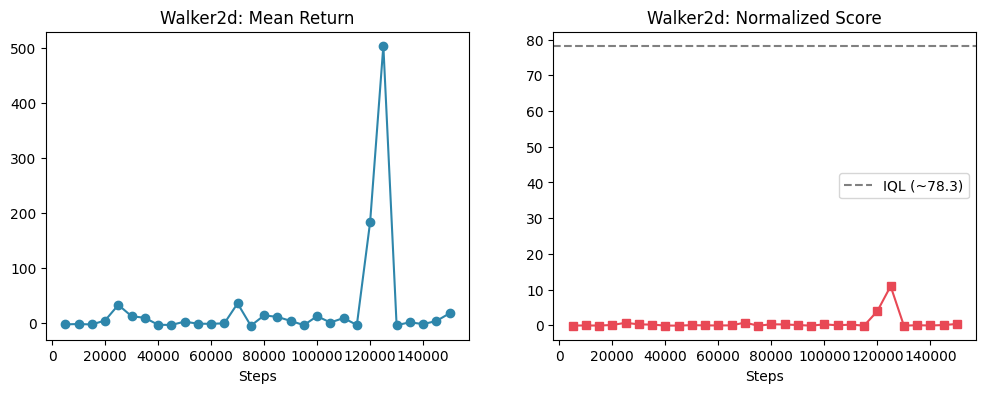

In [9]:
# ================================================================
# EXPERIMENT 3: Walker2d-v4
# ================================================================

# 1. Download Dataset
WALK_URL = "http://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/walker2d_medium-v2.hdf5"
WALK_PATH = "/content/walker2d_medium_v2.hdf5"

if not os.path.exists(WALK_PATH):
    print("Downloading Walker2d dataset...")
    urllib.request.urlretrieve(WALK_URL, WALK_PATH)
print("Walker2d dataset ready.")

# Load dataset
with h5py.File(WALK_PATH, 'r') as f:
    dataset_walk = {
        'observations':      np.array(f['observations'],      dtype=np.float32),
        'actions':           np.array(f['actions'],           dtype=np.float32),
        'rewards':           np.array(f['rewards'],           dtype=np.float32),
        'next_observations': np.array(f['next_observations'], dtype=np.float32),
        'terminals':         np.array(f['terminals'],         dtype=np.float32),
    }

# 2. Setup Environment & Agent
env_walk = gym.make("Walker2d-v4")
STATE_DIM_W  = env_walk.observation_space.shape[0]
ACTION_DIM_W = env_walk.action_space.shape[0]
MAX_ACTION_W = float(env_walk.action_space.high[0])

buffer_walk = OfflineBuffer(dataset_walk, device=DEVICE, normalize_rewards=True)

agent_walk = DMGAgent(
    state_dim=STATE_DIM_W, action_dim=ACTION_DIM_W, max_action=MAX_ACTION_W,
    lam=0.25, nu=0.1, tau=0.7, T=5, n_candidates=10, device=DEVICE
)

# Walker2d D4RL Constants
WALK_RANDOM = 1.629008
WALK_EXPERT = 4592.3
def norm_score_walk(ret): return (ret - WALK_RANDOM) / (WALK_EXPERT - WALK_RANDOM) * 100

# 3. Training Loop (50,000 steps)
eval_steps_w, eval_returns_w, eval_nscores_w = [], [], []

print(f"\nTraining Walker2d | State Dim: {STATE_DIM_W} | Action Dim: {ACTION_DIM_W}")
for step in tqdm(range(1, N_STEPS + 1), desc="Training Walker2d"):
    batch = buffer_walk.sample(256)
    agent_walk.train_step(batch)

    if step % EVAL_FREQ == 0:
        agent_walk.eval()
        rets = []
        for ep in range(5):
            s, _ = env_walk.reset(seed=ep)
            done, ep_ret = False, 0.0
            while not done:
                a = agent_walk.select_action(s)
                s, r, term, trunc, _ = env_walk.step(a)
                ep_ret += r
                done = term or trunc
            rets.append(ep_ret)
        mean_r = np.mean(rets)
        norm_s = norm_score_walk(mean_r)
        eval_steps_w.append(step)
        eval_returns_w.append(mean_r)
        eval_nscores_w.append(norm_s)
        tqdm.write(f"[Step {step:>5d}] Return: {mean_r:.1f} | Norm Score: {norm_s:.1f}")
        agent_walk.train()

# 4. Plot Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(eval_steps_w, eval_returns_w, marker='o', color='#2E86AB')
ax1.set_title("Walker2d: Mean Return"); ax1.set_xlabel("Steps")
ax2.plot(eval_steps_w, eval_nscores_w, marker='s', color='#E84855')
ax2.axhline(78.3, color='gray', linestyle='--', label='IQL (~78.3)')
ax2.set_title("Walker2d: Normalized Score"); ax2.set_xlabel("Steps"); ax2.legend()
plt.savefig("./dmg_results_walker2d.png", bbox_inches='tight')
plt.show()

In [13]:
import pyvirtualdisplay

# Force restart the virtual display and bind it to the environment
try:
    display.stop()
except:
    pass

display = pyvirtualdisplay.Display(visible=0, size=(1400, 900))
display.start()
os.environ["DISPLAY"] = f":{display.display}"

print("Virtual display rebooted. Rendering...")


import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import Video
from IPython.display import display as ipydisplay
import glob
import os

HOPPER_VIDEO_DIR = "./dmg_demo_hopper"
WALKER_VIDEO_DIR = "./dmg_demo_walker"
N_DEMO_EPISODES = 3

# ==========================================
# 1. Record Hopper Video
# ==========================================
print("Recording Hopper...")
base_env_hop = gym.make("Hopper-v4", render_mode="rgb_array", camera_name="track")
env_hop_vid = RecordVideo(
    base_env_hop,
    video_folder=HOPPER_VIDEO_DIR,
    episode_trigger=lambda ep: True,
    name_prefix="dmg_hopper"
)

for ep in range(N_DEMO_EPISODES):
    obs, _ = env_hop_vid.reset(seed=42 + ep)
    done = False
    while not done:
        action = agent_hop.select_action(obs)
        obs, _, term, trunc, _ = env_hop_vid.step(action)
        done = term or trunc
env_hop_vid.close()
print(f"Hopper video saved to {HOPPER_VIDEO_DIR}")

# ==========================================
# 2. Record Walker2d Video
# ==========================================
print("Recording Walker2d...")
base_env_walk = gym.make("Walker2d-v4", render_mode="rgb_array", camera_name="track")
env_walk_vid = RecordVideo(
    base_env_walk,
    video_folder=WALKER_VIDEO_DIR,
    episode_trigger=lambda ep: True,
    name_prefix="dmg_walker2d"
)

for ep in range(N_DEMO_EPISODES):
    obs, _ = env_walk_vid.reset(seed=42 + ep)
    done = False
    while not done:
        action = agent_walk.select_action(obs)
        obs, _, term, trunc, _ = env_walk_vid.step(action)
        done = term or trunc
env_walk_vid.close()
print(f"Walker2d video saved to {WALKER_VIDEO_DIR}")

# ==========================================
# 3. Play the Hopper Video (Change path for Walker2d)
# ==========================================
mp4_files = glob.glob(f"{HOPPER_VIDEO_DIR}/*.mp4")
if mp4_files:
    latest_video = max(mp4_files, key=os.path.getctime)
    print(f"\nPlaying: {latest_video}")
    ipydisplay(Video(latest_video, embed=True, width=640))

Virtual display rebooted. Rendering...
Recording Hopper...


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/dmg_demo_hopper folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Hopper video saved to ./dmg_demo_hopper
Recording Walker2d...


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Walker2d-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/dmg_demo_walker folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Walker2d video saved to ./dmg_demo_walker

Playing: ./dmg_demo_hopper/dmg_hopper-episode-2.mp4
